# Ramulator 2 Tutorial Notebook

## 1. Setup

Before executing the notebook, please build Ramulator first with the following steps (from repository root)
```
mkdir build
cmake ..
make -j2
```

The first cell finds the repository root and adds the local `python/` package directory to `sys.path`. This lets the notebook work when opened either from the repository root or from `examples/`.

In [36]:
from pathlib import Path
from pprint import pprint
import random
import sys
import tempfile


def find_repo_root(start=None):
    current = Path.cwd().resolve() if start is None else Path(start).resolve()
    for path in (current, *current.parents):
        if (path / "pyproject.toml").exists() and (path / "python" / "ramulator").exists():
            return path
    raise RuntimeError("Could not find the Ramulator 2 repository root")


REPO_ROOT = find_repo_root()
PYTHON_DIR = REPO_ROOT / "python"
if str(PYTHON_DIR) not in sys.path:
    sys.path.insert(0, str(PYTHON_DIR))

import matplotlib.pyplot as plt
import ramulator

print(f"Repository root: {REPO_ROOT}")

Repository root: /home/dev/ramulator2


In [37]:
def extract_dram_layout(dram):
    """Return address-generation kwargs for LatencyThroughputTrace."""
    cls = type(dram)
    level_names = list(cls.levels.keys())
    org_dict, _ = dram.resolve()
    org_counts = [org_dict.get(name.lower(), 1) for name in level_names]

    row_idx = level_names.index("Row")
    col_idx = level_names.index("Column")
    bank_positions = list(range(1, row_idx))
    bank_counts = [org_counts[i] for i in bank_positions]

    if "BankGroup" in level_names:
        bg_idx_in_banks = level_names.index("BankGroup") - 1
        if bg_idx_in_banks < len(bank_positions) - 1:
            bank_positions.append(bank_positions.pop(bg_idx_in_banks))
            bank_counts.append(bank_counts.pop(bg_idx_in_banks))

    if "PseudoChannel" in level_names:
        pc_level = level_names.index("PseudoChannel")
        pc_idx_in_banks = [i for i, pos in enumerate(bank_positions) if pos == pc_level][0]
        bank_positions.append(bank_positions.pop(pc_idx_in_banks))
        bank_counts.append(bank_counts.pop(pc_idx_in_banks))

    total_bank_units = 1
    for count in bank_counts:
        total_bank_units *= count

    internal_prefetch_size = cls.internal_prefetch_size
    num_cols = org_counts[col_idx]

    return {
        "addr_vec_size": len(level_names),
        "bank_positions": bank_positions,
        "bank_counts": bank_counts,
        "total_bank_units": total_bank_units,
        "row_pos": row_idx,
        "col_pos": col_idx,
        "num_rows": org_counts[row_idx],
        "num_cols": num_cols,
        "internal_prefetch_size": internal_prefetch_size,
        "num_cls": num_cols // internal_prefetch_size,
    }


def run_sim(frontend, memory_system):
    sim = ramulator.Simulation(frontend, memory_system)
    sim.run()
    return sim.stats


def summarize_stats(stats):
    ctrl = stats["memory_system"]["controller"]
    summary = {
        "cycles": ctrl["cycles"],
        "read_reqs": ctrl["num_read_reqs"],
        "write_reqs": ctrl["num_write_reqs"],
        "read_reqs_served": ctrl["num_read_reqs_served"],
        "write_reqs_served": ctrl["num_write_reqs_served"],
        "avg_read_latency_cycles": round(float(ctrl["avg_read_latency"]), 2),
        "read_queue_len_avg": round(float(ctrl["read_queue_len_avg"]), 3),
        "write_queue_len_avg": round(float(ctrl["write_queue_len_avg"]), 3),
        "total_throughput_GBps": round(float(ctrl["total_throughput_MBps"]) / 1000.0, 3),
        "row_hits": ctrl["row_hits"],
        "row_misses": ctrl["row_misses"],
        "row_conflicts": ctrl["row_conflicts"],
    }
    frontend = stats.get("frontend", {})
    if "avg_probe_latency" in frontend:
        summary.update(
            {
                "avg_probe_latency_cycles": round(float(frontend["avg_probe_latency"]), 2),
                "probe_requests_completed": frontend["probe_requests_completed"],
                "streaming_requests_sent": frontend["streaming_requests_sent"],
            }
        )
    return summary



def plot_lat_tp_curves(rows, *, group_key="label", title="Latency-Throughput Curves"):
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    groups = list(dict.fromkeys(row[group_key] for row in rows))
    for group in groups:
        points = [row for row in rows if row[group_key] == group]
        points.sort(key=lambda row: -row["nop_counter"])
        ax.plot(
            [row["total_throughput_GBps"] for row in points],
            [row["avg_probe_latency_ns"] for row in points],
            marker="o",
            linewidth=2,
            markersize=4,
            label=str(group),
        )
    ax.set_title(title)
    ax.set_xlabel("Total throughput (GB/s)")
    ax.set_ylabel("Average probe latency (ns)")
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.legend(title=group_key.replace("_", " "))
    fig.tight_layout()
    plt.show()


def plot_lat_tp_grid(rows, *, group_key="queue_depth", title="Latency-Throughput Curves"):
    groups = sorted({row[group_key] for row in rows})
    ncols = 3
    nrows = (len(groups) + ncols - 1) // ncols
    x_values = [row["total_throughput_GBps"] for row in rows]
    y_values = [row["avg_probe_latency_ns"] for row in rows]
    x_pad = max((max(x_values) - min(x_values)) * 0.05, 0.1)
    y_pad = max((max(y_values) - min(y_values)) * 0.05, 1.0)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(ncols * 4.0, nrows * 3.0),
        sharex=True,
        sharey=True,
        squeeze=False,
    )
    for ax, group in zip(axes.flat, groups):
        points = [row for row in rows if row[group_key] == group]
        points.sort(key=lambda row: -row["nop_counter"])
        ax.plot(
            [row["total_throughput_GBps"] for row in points],
            [row["avg_probe_latency_ns"] for row in points],
            marker="o",
            linewidth=2,
            markersize=3.5,
        )
        ax.set_title(f"{group_key.replace('_', ' ')} = {group}")
        ax.set_xlim(min(x_values) - x_pad, max(x_values) + x_pad)
        ax.set_ylim(min(y_values) - y_pad, max(y_values) + y_pad)
        ax.grid(True, linestyle=":", alpha=0.5)

    for ax in axes.flat[len(groups):]:
        ax.set_visible(False)
    for ax in axes[-1, :]:
        if ax.get_visible():
            ax.set_xlabel("Total throughput (GB/s)")
    for ax in axes[:, 0]:
        ax.set_ylabel("Average probe latency (ns)")

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def summarize_lat_tp_sweeps(rows, *, group_key="label"):
    summary = []
    groups = list(dict.fromkeys(row[group_key] for row in rows))
    for group in groups:
        points = [row for row in rows if row[group_key] == group]
        max_tp = max(points, key=lambda row: row["total_throughput_GBps"])
        unloaded = max(points, key=lambda row: row["nop_counter"])
        first = points[0]
        summary.append(
            {
                group_key: group,
                "read_ratio": first["read_ratio"],
                "nop_points": len(points),
                "nop_min": min(row["nop_counter"] for row in points),
                "nop_max": max(row["nop_counter"] for row in points),
                "bank_units": first["bank_units"],
                "queue_depth": first["queue_depth"],
                "max_throughput_GBps": max_tp["total_throughput_GBps"],
                "latency_at_max_throughput_ns": max_tp["avg_probe_latency_ns"],
                "unloaded_latency_ns": unloaded["avg_probe_latency_ns"],
                "unloaded_throughput_GBps": unloaded["total_throughput_GBps"],
            }
        )
    return summary

## 2. Random SimpleO3 End-to-End Run

This tutorial starts by generating a random SimpleO3 instruction trace. SimpleO3 trace lines use the format `<bubble_count> <load_addr> [store_addr]`, where the optional third field creates a store/writeback. The generated trace is then used by `ramulator.frontend.SimpleO3` to drive a full frontend, LLC, controller, and DRAM simulation.

In [38]:
def generate_random_simple_o3_trace(
    path,
    *,
    num_lines=4096,
    seed=2026,
    max_addr=2**31,
    store_ratio=0.20,
):
    rng = random.Random(seed)
    max_cacheline = max_addr // 64
    hot_cachelines = [rng.randrange(max_cacheline) for _ in range(256)]
    lines = []

    for _ in range(num_lines):
        bubble_count = rng.randrange(0, 9)
        if rng.random() < 0.65:
            load_cacheline = rng.choice(hot_cachelines)
        else:
            load_cacheline = rng.randrange(max_cacheline)
        load_addr = load_cacheline * 64

        if rng.random() < store_ratio:
            if rng.random() < 0.50:
                store_cacheline = load_cacheline
            else:
                store_cacheline = rng.randrange(max_cacheline)
            lines.append(f"{bubble_count} {load_addr} {store_cacheline * 64}")
        else:
            lines.append(f"{bubble_count} {load_addr}")

    path.write_text("\n".join(lines) + "\n")
    return lines


trace_tmpdir = tempfile.TemporaryDirectory(prefix="ramulator2_tutorial_")
trace_path = Path(trace_tmpdir.name) / "random_simple_o3.trace"
trace_preview = generate_random_simple_o3_trace(trace_path)

print(f"Generated {len(trace_preview)} SimpleO3 trace lines at {trace_path}")
print("Trace preview:")
for line in trace_preview[:8]:
    print(line)

Generated 4096 SimpleO3 trace lines at /tmp/ramulator2_tutorial_39_s9ykh/random_simple_o3.trace
Trace preview:
4 1530373760 101633152
4 1243632192
1 1132637504
0 1645768512 1645768512
1 2056829312 2056829312
5 298536576 1528885696
6 687716608
3 787985216


In [39]:
dram = ramulator.dram.DDR4(
    org_preset="DDR4_8Gb_x8",
    timing_preset="DDR4_2400R",
    rank=1,
)
frontend = ramulator.frontend.SimpleO3(
    clock_ratio=8,
    traces=[str(trace_path)],
    num_expected_insts=50_000,
    ipc=4,
    inst_window_depth=128,
    llc_capacity_per_core="256KB",
    llc_num_mshr_per_core=32,
    translation=ramulator.translation.NoTranslation(max_addr=2**31),
)
ctrl = ramulator.controller.GenericDDR(
    dram=dram,
    scheduler=ramulator.scheduler.FRFCFSRowHit(),
    refresh_manager=ramulator.refresh_manager.AllBank(),
    row_policy=ramulator.row_policy.Open(),
    addr_mapper=ramulator.addr_mapper.RoBaRaCoCh(),
)
mem = ramulator.memory_system.GenericDRAM(
    clock_ratio=3,
    controllers=[ctrl],
    channel_mapper=ramulator.channel_mapper.CacheLineInterleave(),
)

stats = run_sim(frontend, mem)
stats

{'frontend': {'cycles_recorded_core_0': 72194,
  'impl': 'SimpleO3',
  'llc_eviction': 87,
  'llc_mshr_unavailable': 127,
  'llc_read_access': 10121,
  'llc_read_misses': 1816,
  'llc_write_access': 2085,
  'llc_write_misses': 600,
  'memory_access_cycles_recorded_core_0': 23357,
  'num_expected_insts': 50000,
  'translation': {'impl': 'NoTranslation'}},
 'memory_system': {'channel_mapper': {'impl': 'CacheLineInterleave'},
  'controller': {'addr_mapper': {'impl': 'RoBaRaCoCh'},
   'avg_read_latency': 87.590691,
   'cycles': 27073,
   'id': 'Channel 0',
   'impl': 'GenericDDR',
   'num_maintenance_reqs': 2,
   'num_maintenance_reqs_served': 2,
   'num_read_reqs': 2106,
   'num_read_reqs_forwarded': 0,
   'num_read_reqs_served': 2106,
   'num_write_reqs': 31,
   'num_write_reqs_coalesced': 0,
   'num_write_reqs_served': 31,
   'priority_queue_len': 83,
   'priority_queue_len_avg': 0.003066,
   'queue_len': 112542,
   'queue_len_avg': 4.156983,
   'read_latency': 184466,
   'read_queue_le

## 3. DDR5 Latency-Throughput Testcase Setup

In [ ]:
DDR5_ORG_PRESET = "DDR5_16Gb_x8"
DDR5_TIMING_PRESET = "DDR5_4800AN"
DDR5_FRONTEND_CLOCK_RATIO = 8
DDR5_STREAM_CLS = 64
DDR5_READ_RATIO = 90
DDR5_LATENCY_SAMPLE_COUNT = 256
DDR5_WARMUP_CYCLES = 1000
DDR5_NOP_COUNTERS = (
    1, 33, 36, 38, 41, 44, 47, 50, 52, 55, 58, 65, 70, 80,
    90, 100, 125, 150, 200, 300, 500, 750, 1000, 2000,
    5000, 10000,
)


def make_ddr5_dram(*, bank=4, row=1 << 16):
    return ramulator.dram.DDR5(
        org_preset=DDR5_ORG_PRESET,
        timing_preset=DDR5_TIMING_PRESET,
        bank=bank,
        row=row,
    )


def run_ddr5_point(
    label,
    *,
    bank=4,
    row=1 << 16,
    queue_depth=32,
    nop_counter=DDR5_NOP_COUNTERS[0],
    read_ratio=DDR5_READ_RATIO,
    latency_sample_count=DDR5_LATENCY_SAMPLE_COUNT,
    warmup_cycles=DDR5_WARMUP_CYCLES,
    seed=12345,
):
    dram = make_ddr5_dram(bank=bank, row=row)
    layout = extract_dram_layout(dram)
    org_dict, timing_dict = dram.resolve()
    tck_ns = timing_dict["tCK_ps"] / 1000.0

    frontend = ramulator.frontend.LatencyThroughputTrace(
        clock_ratio=DDR5_FRONTEND_CLOCK_RATIO,
        nop_counter=nop_counter,
        num_probe_requests=latency_sample_count,
        latency_sample_count=latency_sample_count,
        warmup_cycles=warmup_cycles,
        seed=seed,
        read_ratio=read_ratio,
        stream_cls=DDR5_STREAM_CLS,
        stagger_stream_rows=True,
        **layout,
    )
    ctrl = ramulator.controller.GenericDDR(
        dram=dram,
        scheduler=ramulator.scheduler.FRFCFSRowHit(),
        refresh_manager=ramulator.refresh_manager.NoRefresh(),
        row_policy=ramulator.row_policy.Open(),
        addr_mapper=ramulator.addr_mapper.PassThroughAddrMapper(),
        read_buffer_size=queue_depth,
        write_buffer_size=queue_depth,
    )
    mem = ramulator.memory_system.GenericDRAM(
        clock_ratio=1,
        controllers=[ctrl],
        channel_mapper=ramulator.channel_mapper.PassThroughChannelMapper(),
    )
    stats = run_sim(frontend, mem)
    ctrl_stats = stats["memory_system"]["controller"]
    frontend_stats = stats["frontend"]

    return {
        "label": label,
        "bank_groups": org_dict["bankgroup"],
        "banks_per_group": org_dict["bank"],
        "rows": org_dict["row"],
        "bank_units": layout["total_bank_units"],
        "queue_depth": queue_depth,
        "nop_counter": nop_counter,
        "read_ratio": read_ratio,
        "samples": latency_sample_count,
        "avg_probe_latency_cycles": round(float(frontend_stats["avg_probe_latency"]), 2),
        "avg_probe_latency_ns": round(float(frontend_stats["avg_probe_latency"]) * tck_ns, 2),
        "avg_read_latency_cycles": round(float(ctrl_stats["avg_read_latency"]), 2),
        "avg_read_latency_ns": round(float(ctrl_stats["avg_read_latency"]) * tck_ns, 2),
        "total_throughput_GBps": round(float(ctrl_stats["total_throughput_MBps"]) / 1000.0, 3),
        "read_queue_len_avg": round(float(ctrl_stats["read_queue_len_avg"]), 3),
        "write_queue_len_avg": round(float(ctrl_stats["write_queue_len_avg"]), 3),
        "row_hits": ctrl_stats["row_hits"],
        "row_misses": ctrl_stats["row_misses"],
        "row_conflicts": ctrl_stats["row_conflicts"],
        "streaming_requests_sent": frontend_stats["streaming_requests_sent"],
    }


def run_ddr5_sweep(label, **kwargs):
    return [
        run_ddr5_point(label, nop_counter=nop_counter, **kwargs)
        for nop_counter in DDR5_NOP_COUNTERS
    ]


ddr5_base = make_ddr5_dram()
print("DDR5 testcase organization:")
pprint(ddr5_base.resolve()[0])

DDR5 testcase organization:
{'bank': 4,
 'bankgroup': 8,
 'channel_width': 32,
 'column': 1024,
 'density': 16384,
 'dq': 8,
 'rank': 1,
 'row': 65536}

DDR5 address-generation layout:
{'addr_vec_size': 6,
 'bank_counts': [1, 4, 8],
 'bank_positions': [1, 3, 2],
 'col_pos': 5,
 'internal_prefetch_size': 16,
 'num_cls': 64,
 'num_cols': 1024,
 'num_rows': 65536,
 'row_pos': 4,
 'total_bank_units': 32}

DDR5 90% read NOP counters:
(1,
 33,
 36,
 38,
 41,
 44,
 47,
 50,
 52,
 55,
 58,
 65,
 70,
 80,
 90,
 100,
 125,
 150,
 200,
 300,
 500,
 750,
 1000,
 2000,
 5000,
 10000)


## 4. Effect of Bank Count on Latency-Throughput Curve

[Ramulator::LatencyThroughputTrace] [info] LatencyThroughputTrace: nop_counter=1, latency_mode=random-probe, samples=256, warmup=1000, bank_units=32
[Ramulator::LatencyThroughputTrace] [info] LatencyThroughputTrace: nop_counter=33, latency_mode=random-probe, samples=256, warmup=1000, bank_units=32
[Ramulator::LatencyThroughputTrace] [info] LatencyThroughputTrace: nop_counter=36, latency_mode=random-probe, samples=256, warmup=1000, bank_units=32
[Ramulator::LatencyThroughputTrace] [info] LatencyThroughputTrace: nop_counter=38, latency_mode=random-probe, samples=256, warmup=1000, bank_units=32
[Ramulator::LatencyThroughputTrace] [info] LatencyThroughputTrace: nop_counter=41, latency_mode=random-probe, samples=256, warmup=1000, bank_units=32
[Ramulator::LatencyThroughputTrace] [info] LatencyThroughputTrace: nop_counter=44, latency_mode=random-probe, samples=256, warmup=1000, bank_units=32
[Ramulator::LatencyThroughputTrace] [info] LatencyThroughputTrace: nop_counter=47, latency_mode=rando

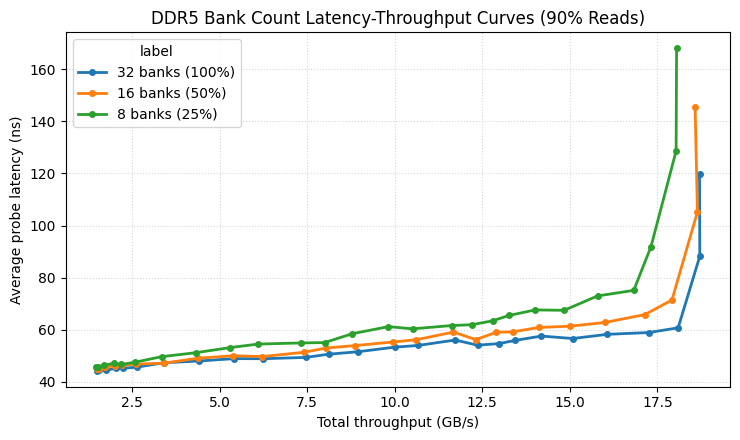

Ran 78 points: 3 variants x 26 NOP counters
[{'bank_units': 32,
  'label': '32 banks (100%)',
  'latency_at_max_throughput_ns': 88.23,
  'max_throughput_GBps': 18.713,
  'nop_max': 10000,
  'nop_min': 1,
  'nop_points': 26,
  'queue_depth': 32,
  'read_ratio': 90,
  'unloaded_latency_ns': 44.27,
  'unloaded_throughput_GBps': 1.502},
 {'bank_units': 16,
  'label': '16 banks (50%)',
  'latency_at_max_throughput_ns': 105.18,
  'max_throughput_GBps': 18.645,
  'nop_max': 10000,
  'nop_min': 1,
  'nop_points': 26,
  'queue_depth': 32,
  'read_ratio': 90,
  'unloaded_latency_ns': 45.03,
  'unloaded_throughput_GBps': 1.482},
 {'bank_units': 8,
  'label': '8 banks (25%)',
  'latency_at_max_throughput_ns': 168.01,
  'max_throughput_GBps': 18.05,
  'nop_max': 10000,
  'nop_min': 1,
  'nop_points': 26,
  'queue_depth': 32,
  'read_ratio': 90,
  'unloaded_latency_ns': 45.56,
  'unloaded_throughput_GBps': 1.465}]


[{'label': '32 banks (100%)',
  'read_ratio': 90,
  'nop_points': 26,
  'nop_min': 1,
  'nop_max': 10000,
  'bank_units': 32,
  'queue_depth': 32,
  'max_throughput_GBps': 18.713,
  'latency_at_max_throughput_ns': 88.23,
  'unloaded_latency_ns': 44.27,
  'unloaded_throughput_GBps': 1.502},
 {'label': '16 banks (50%)',
  'read_ratio': 90,
  'nop_points': 26,
  'nop_min': 1,
  'nop_max': 10000,
  'bank_units': 16,
  'queue_depth': 32,
  'max_throughput_GBps': 18.645,
  'latency_at_max_throughput_ns': 105.18,
  'unloaded_latency_ns': 45.03,
  'unloaded_throughput_GBps': 1.482},
 {'label': '8 banks (25%)',
  'read_ratio': 90,
  'nop_points': 26,
  'nop_min': 1,
  'nop_max': 10000,
  'bank_units': 8,
  'queue_depth': 32,
  'max_throughput_GBps': 18.05,
  'latency_at_max_throughput_ns': 168.01,
  'unloaded_latency_ns': 45.56,
  'unloaded_throughput_GBps': 1.465}]

In [ ]:
bank_variants = sorted(
    [
        {"label": "32 banks", "bank_units": 32, "bank": 4, "row": 1 << 16},
        {"label": "16 banks", "bank_units": 16, "bank": 2, "row": 1 << 17},
        {"label": "8 banks", "bank_units": 8, "bank": 1, "row": 1 << 18},
    ],
    key=lambda variant: variant["bank_units"],
    reverse=True,
)

bank_results = [
    row
    for variant in bank_variants
    for row in run_ddr5_sweep(
        variant["label"],
        bank=variant["bank"],
        row=variant["row"],
        queue_depth=32,
    )
]
bank_summary = summarize_lat_tp_sweeps(bank_results)

plot_lat_tp_curves(
    bank_results,
    title="DDR5 Bank Count Latency-Throughput Curves (90% Reads)",
)

print(f"Ran {len(bank_results)} points: {len(bank_variants)} variants x {len(DDR5_NOP_COUNTERS)} NOP counters")
pprint(bank_summary)
bank_summary

## 5. Effect of Memory Controller Queue Depth

[Ramulator::LatencyThroughputTrace] [info] LatencyThroughputTrace: nop_counter=1, latency_mode=random-probe, samples=256, warmup=1000, bank_units=32
[Ramulator::LatencyThroughputTrace] [info] LatencyThroughputTrace: nop_counter=33, latency_mode=random-probe, samples=256, warmup=1000, bank_units=32
[Ramulator::LatencyThroughputTrace] [info] LatencyThroughputTrace: nop_counter=36, latency_mode=random-probe, samples=256, warmup=1000, bank_units=32
[Ramulator::LatencyThroughputTrace] [info] LatencyThroughputTrace: nop_counter=38, latency_mode=random-probe, samples=256, warmup=1000, bank_units=32
[Ramulator::LatencyThroughputTrace] [info] LatencyThroughputTrace: nop_counter=41, latency_mode=random-probe, samples=256, warmup=1000, bank_units=32
[Ramulator::LatencyThroughputTrace] [info] LatencyThroughputTrace: nop_counter=44, latency_mode=random-probe, samples=256, warmup=1000, bank_units=32
[Ramulator::LatencyThroughputTrace] [info] LatencyThroughputTrace: nop_counter=47, latency_mode=rando

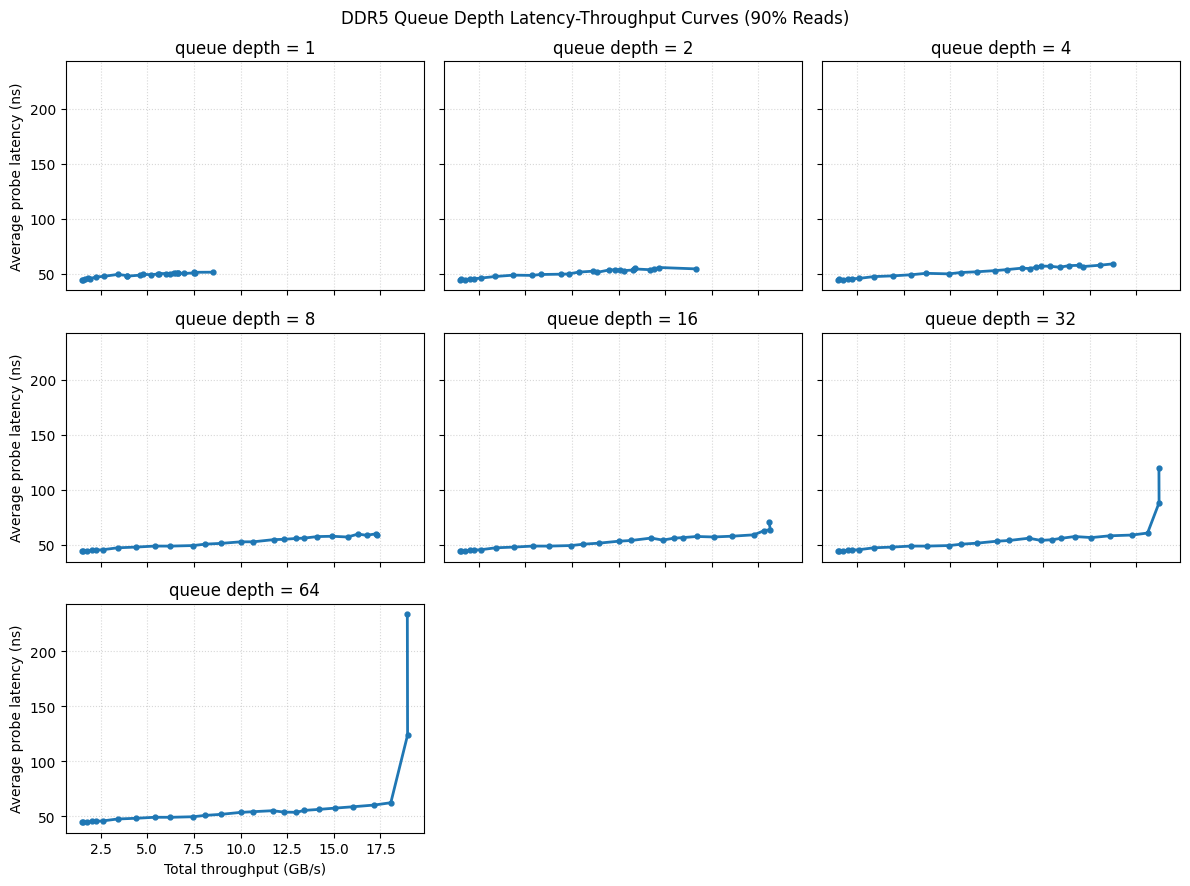

Ran 182 points: 7 queue depths x 26 NOP counters
[{'bank_units': 32,
  'label': 'depth 1',
  'latency_at_max_throughput_ns': 51.3,
  'max_throughput_GBps': 8.509,
  'nop_max': 10000,
  'nop_min': 1,
  'nop_points': 26,
  'queue_depth': 1,
  'read_ratio': 90,
  'unloaded_latency_ns': 44.27,
  'unloaded_throughput_GBps': 1.489},
 {'bank_units': 32,
  'label': 'depth 2',
  'latency_at_max_throughput_ns': 54.31,
  'max_throughput_GBps': 14.161,
  'nop_max': 10000,
  'nop_min': 1,
  'nop_points': 26,
  'queue_depth': 2,
  'read_ratio': 90,
  'unloaded_latency_ns': 44.27,
  'unloaded_throughput_GBps': 1.502},
 {'bank_units': 32,
  'label': 'depth 4',
  'latency_at_max_throughput_ns': 58.89,
  'max_throughput_GBps': 16.238,
  'nop_max': 10000,
  'nop_min': 1,
  'nop_points': 26,
  'queue_depth': 4,
  'read_ratio': 90,
  'unloaded_latency_ns': 44.27,
  'unloaded_throughput_GBps': 1.502},
 {'bank_units': 32,
  'label': 'depth 8',
  'latency_at_max_throughput_ns': 58.61,
  'max_throughput_GBps':

[{'label': 'depth 1',
  'read_ratio': 90,
  'nop_points': 26,
  'nop_min': 1,
  'nop_max': 10000,
  'bank_units': 32,
  'queue_depth': 1,
  'max_throughput_GBps': 8.509,
  'latency_at_max_throughput_ns': 51.3,
  'unloaded_latency_ns': 44.27,
  'unloaded_throughput_GBps': 1.489},
 {'label': 'depth 2',
  'read_ratio': 90,
  'nop_points': 26,
  'nop_min': 1,
  'nop_max': 10000,
  'bank_units': 32,
  'queue_depth': 2,
  'max_throughput_GBps': 14.161,
  'latency_at_max_throughput_ns': 54.31,
  'unloaded_latency_ns': 44.27,
  'unloaded_throughput_GBps': 1.502},
 {'label': 'depth 4',
  'read_ratio': 90,
  'nop_points': 26,
  'nop_min': 1,
  'nop_max': 10000,
  'bank_units': 32,
  'queue_depth': 4,
  'max_throughput_GBps': 16.238,
  'latency_at_max_throughput_ns': 58.89,
  'unloaded_latency_ns': 44.27,
  'unloaded_throughput_GBps': 1.502},
 {'label': 'depth 8',
  'read_ratio': 90,
  'nop_points': 26,
  'nop_min': 1,
  'nop_max': 10000,
  'bank_units': 32,
  'queue_depth': 8,
  'max_throughput_

In [42]:
queue_depths = [1, 2, 4, 8, 16, 32, 64]
queue_results = [
    row
    for depth in queue_depths
    for row in run_ddr5_sweep(
        f"depth {depth}",
        queue_depth=depth,
    )
]
queue_summary = summarize_lat_tp_sweeps(queue_results)

plot_lat_tp_grid(
    queue_results,
    group_key="queue_depth",
    title="DDR5 Queue Depth Latency-Throughput Curves (90% Reads)",
)

print(f"Ran {len(queue_results)} points: {len(queue_depths)} queue depths x {len(DDR5_NOP_COUNTERS)} NOP counters")
pprint(queue_summary)
queue_summary